In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pmt.io import (
    find_pmt_files,
    load_baseline_subtracted_waveforms,
    read_waveform_sample,
)
from pmt.preprocessing import subtract_baseline
from pmt.config import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})


# Select Files


In [2]:
file_name = "WA0089_850V_20MHz_Cold_led1"
# file_name = "WA0089_850V_20MHz_Cold_led2"
# file_name = "WA0089_850V_20MHz_Cold_led3"
# file_name = "WA0089_850V_20MHz_Cold_led4"
# file_name = "WA0089_850V_20MHz_Cold_led5"
# file_name = "WA0089_850V_20MHz_Cold_led6"
# file_name = "WA0089_850V_20MHz_Cold_led7"
# file_name = "WA0089_850V_20MHz_Cold_led8"
# file_name = "WA0089_850V_20MHz_Cold_led9"
data_dir = Path("data/WA0089/LED_sweep/260615")

# Set to a number for quick iteration, or None to use all matching files.
max_files = 1

files = find_pmt_files(data_dir, file_name, max_files=max_files)

for file in files:
    print(file)
print(f"Number of files loaded: {len(files)}")


data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-1.h5
Number of files loaded: 1


# Configuration

In [5]:
cfg = load_config("config_default.yml", file_name)
print(cfg)


[general]
baseline_window_width_ns = 20
integration_window_ns = (30, 80)
peak_search_window_ns = (30, 80)
global_peak_voltage_max_mV = None
out_of_window_peak_voltage_max_mV = -1.0
allowed_peak_window_ns = (30, 40)

[fit_general]
fit_range = (-15.0, 80.0)
fit_nbins = 250



In [8]:
cfg.general.baseline_window_width_ns

20

In [3]:
rise_low_fraction = 0.1
rise_high_fraction = 0.9
show_residual_errorbars = True
chunk_size = 4096

config_wrapped, config = load_selection_config(
    "config_default.yml",
    config_name,
    time_ns,
    rise_low_fraction=rise_low_fraction,
    rise_high_fraction=rise_high_fraction,
)

baseline_window_ns = config_wrapped["baseline_window_ns"]
integration_window_ns = config_wrapped["integration_window_ns"]
peak_search_window_ns = config_wrapped["peak_search_window_ns"]
allowed_peak_window_ns = config_wrapped["allowed_peak_window_ns"]
global_peak_voltage_max_mV = config_wrapped["global_peak_voltage_max_mV"]
out_of_window_peak_voltage_max_mV = config_wrapped["out_of_window_peak_voltage_max_mV"]
real_peak_threshold_amplitude_mV = (
    abs(out_of_window_peak_voltage_max_mV) if out_of_window_peak_voltage_max_mV is not None else None
)

config_wrapped


NameError: name 'load_selection_config' is not defined

# 1. Small Sample


Use this small sample for fast checks, plots, and choosing analysis settings.


In [ ]:
max_sample_events = 5000

sample = read_waveform_sample(files[0], max_events=max_sample_events)

time_ns = sample["time_ns"]
voltage_sample_mV = sample["voltage_mV"]
adc_step_mV = sample["adc_step_mV"]

print(f"Sample waveforms: {voltage_sample_mV.shape}")
print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV")


Sample waveforms: (1000, 1601)
Time range: -0.029 to 99.971 ns
Sampling step: 0.06250 ns
ADC step: 0.000214 mV


## Baseline Settings


In [4]:
baseline_window_width_ns = 20
baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + baseline_window_width_ns))
print(f"Baseline window: {baseline_window_ns[0]:.3f} to {baseline_window_ns[1]:.3f} ns")


Baseline window: -0.029 to 19.971 ns


## Baseline Subtraction (small sample)


In [5]:
voltage_sample_bs_mV, sample_baseline_mV = subtract_baseline(
    time_ns,
    voltage_sample_mV,
    baseline_window_ns=baseline_window_ns,
)

print(f"Baseline-subtracted sample: {voltage_sample_bs_mV.shape}")
print(f"Sample baselines: {sample_baseline_mV.shape}")


Baseline-subtracted sample: (1000, 1601)
Sample baselines: (1000,)


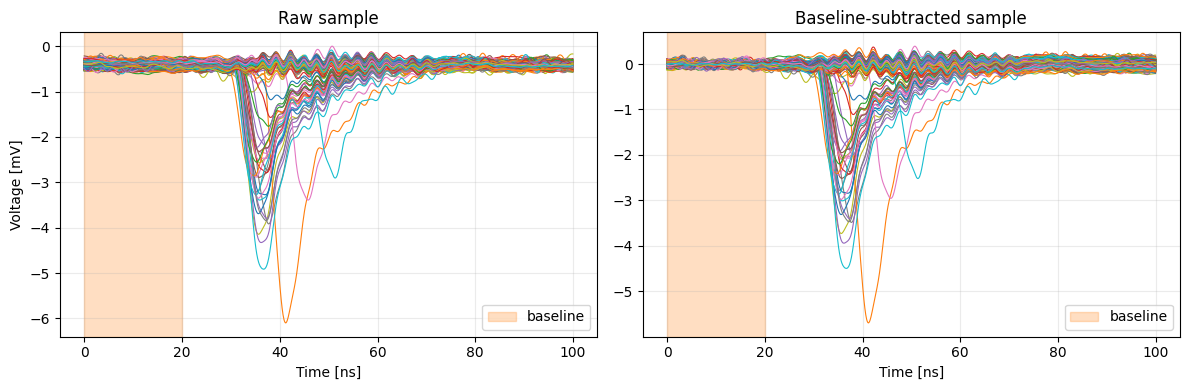

In [6]:
n_to_plot = None

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for waveform in voltage_sample_mV[:n_to_plot]:
    axes[0].plot(time_ns, waveform, lw=0.8)
axes[0].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[0].set_title("Raw sample")
axes[0].set_xlabel("Time [ns]")
axes[0].set_ylabel("Voltage [mV]")
axes[0].legend(loc="lower right")

for waveform in voltage_sample_bs_mV[:n_to_plot]:
    axes[1].plot(time_ns, waveform, lw=0.8)
axes[1].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[1].set_title("Baseline-subtracted sample")
axes[1].set_xlabel("Time [ns]")
axes[1].legend(loc="lower right")

fig.tight_layout()


# 2. Full Sample


Use this path after the small-sample check looks reasonable. It processes every waveform in `files` in chunks.


In [14]:
chunk_size = 512

full_sample = load_baseline_subtracted_waveforms(
    files,
    baseline_window_ns,
    subtract_baseline,
    chunk_size=chunk_size,
)

time_ns_full = full_sample["time_ns"]
voltage_full_bs_mV = full_sample["voltage_bs_mV"]
baseline_full_mV = full_sample["baseline_mV"]

print(f"Full baseline-subtracted sample: {voltage_full_bs_mV.shape}")
print(f"Full sample baselines: {baseline_full_mV.shape}")


Full baseline-subtracted sample: (31682, 1601)
Full sample baselines: (31682,)
